# M26.CSC 7102 / CS 507 — Machine Learning## Assignment 2: Class Imbalance Handling & Hyperparameter Tuning### Fraud Detection in Mobile Money Transactions| | ||---|---|| **Course** | M26.CSC 7102 / CS 507 Machine Learning || **Lecturer** | Dr. Denish Azamuke || **Group Number** | *2* || **Members** | *SSEGAWA ABDULKARIM<br/>MUGAGGA JOHN<br/>ASHABA ANTHONY<br/>MUSEMA MANASH<br/>AHIMNBISIBWE MORDECAI MBABAZI* || **Date** | JUNE 2026 |---This notebook builds on the Assignment 1 pipeline and covers all seven Assignment 2 tasks:class-imbalance analysis, baseline modelling, **four balancing techniques**, **hyperparameter tuning**with `GridSearchCV` / `RandomizedSearchCV`, and a full metric comparison. All balancing is applied**only to the training set** (after the split) to avoid data leakage.

## 0. Run Configuration`SAMPLE_SIZE` controls how many rows are used. Training ensembles on the full **1.72M** rows is slow ona single core, so this notebook was **executed on a stratified sub-sample** (which preserves the exact~10.2% fraud rate) to keep run-time reasonable.**To reproduce on the full dataset, set `SAMPLE_SIZE = None` and re-run all cells.** Nothing else changes.

In [1]:
# ── Run configuration ────────────────────────────────────────────────────SAMPLE_SIZE = 60_000     # set to None to use the FULL datasetSEED = 42

## 1. Imports and Configuration

In [2]:
# ── Standard libraries ───────────────────────────────────────────────────import warningswarnings.filterwarnings('ignore')import numpy as npimport pandas as pdimport matplotlib.pyplot as pltimport seaborn as sns# ── Scikit-learn ─────────────────────────────────────────────────────────from sklearn.model_selection import (    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV)from sklearn.preprocessing import LabelEncoderfrom sklearn.linear_model import LogisticRegressionfrom sklearn.ensemble import RandomForestClassifierfrom sklearn.metrics import (    classification_report, confusion_matrix, ConfusionMatrixDisplay,    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,    f1_score, precision_score, recall_score, accuracy_score)# ── Imbalanced-learn (with portable fallbacks if not installed) ──────────try:    from imblearn.over_sampling import SMOTE, RandomOverSampler    from imblearn.under_sampling import RandomUnderSampler    HAS_IMBLEARN = Trueexcept ImportError:    HAS_IMBLEARN = False    class RandomOverSampler:        """Minimal drop-in: duplicates minority rows until classes balance."""        def __init__(self, random_state=None): self.rs = random_state        def fit_resample(self, X, y):            X = pd.DataFrame(X).reset_index(drop=True); y = pd.Series(y).reset_index(drop=True)            n = y.value_counts().max(); rng = np.random.RandomState(self.rs)            parts_X, parts_y = [], []            for cls, cnt in y.value_counts().items():                idx = y.index[y == cls].to_numpy()                take = rng.choice(idx, size=n, replace=(cnt < n))                parts_X.append(X.iloc[take]); parts_y.append(pd.Series([cls]*n))            return (pd.concat(parts_X).reset_index(drop=True).values,                    pd.concat(parts_y).reset_index(drop=True).values)    class RandomUnderSampler:        """Minimal drop-in: drops majority rows until classes balance."""        def __init__(self, random_state=None): self.rs = random_state        def fit_resample(self, X, y):            X = pd.DataFrame(X).reset_index(drop=True); y = pd.Series(y).reset_index(drop=True)            n = y.value_counts().min(); rng = np.random.RandomState(self.rs)            parts_X, parts_y = [], []            for cls in y.value_counts().index:                idx = y.index[y == cls].to_numpy()                take = rng.choice(idx, size=n, replace=False)                parts_X.append(X.iloc[take]); parts_y.append(pd.Series([cls]*n))            return (pd.concat(parts_X).reset_index(drop=True).values,                    pd.concat(parts_y).reset_index(drop=True).values)    class SMOTE:        """Minimal k-NN SMOTE fallback for the minority class."""        def __init__(self, random_state=None, k_neighbors=5):            self.rs = random_state; self.k = k_neighbors        def fit_resample(self, X, y):            from sklearn.neighbors import NearestNeighbors            X = np.asarray(pd.DataFrame(X)); y = np.asarray(pd.Series(y))            rng = np.random.RandomState(self.rs)            classes, counts = np.unique(y, return_counts=True)            maj = classes[np.argmax(counts)]; n_max = counts.max()            Xs, ys = [X], [y]            for cls in classes:                if cls == maj: continue                Xc = X[y == cls]; need = n_max - len(Xc)                if need <= 0 or len(Xc) <= 1: continue                k = min(self.k, len(Xc) - 1)                nn = NearestNeighbors(n_neighbors=k + 1).fit(Xc)                _, idx = nn.kneighbors(Xc)                base = rng.randint(0, len(Xc), size=need)                neigh = idx[base, rng.randint(1, k + 1, size=need)]                gap = rng.rand(need, 1)                synth = Xc[base] + gap * (Xc[neigh] - Xc[base])                Xs.append(synth); ys.append(np.full(need, cls))            return np.vstack(Xs), np.concatenate(ys)SEED = SEEDnp.random.seed(SEED)sns.set_theme(style='whitegrid', palette='muted')plt.rcParams['figure.dpi'] = 110print("Libraries loaded.  imbalanced-learn available:", HAS_IMBLEARN)

Libraries loaded.  imbalanced-learn available: False


## 2. Task 1 — Dataset & Problem DescriptionFraud detection is a binary classification task: predict whether a mobile-money transaction isfraudulent (`isFraud = 1`) or legitimate (`isFraud = 0`). Fraud is rare, so the data is highlyimbalanced and accuracy alone is misleading; we focus on **precision, recall, F1, ROC-AUC and PR-AUC**.**Dataset:** Synthetic Mobile Money Transaction Dataset (Mendeley `zhj366m53p/1`). **Target:** `isFraud`.

In [3]:
# ── Load dataset (portable relative path) ────────────────────────────────DATA_PATH = 'synthetic_mobile_money_transaction_dataset.csv'df_full = pd.read_csv(DATA_PATH)print(f"Full dataset: {df_full.shape[0]:,} rows x {df_full.shape[1]} columns")# ── Optional stratified sub-sample for faster execution ──────────────────if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df_full):    df, _ = train_test_split(df_full, train_size=SAMPLE_SIZE,                             random_state=SEED, stratify=df_full['isFraud'])    df = df.reset_index(drop=True)    print(f"Using stratified sub-sample: {df.shape[0]:,} rows "          f"(fraud rate {df['isFraud'].mean()*100:.3f}%)")else:    df = df_full.copy()    print("Using the FULL dataset.")df.head()

Full dataset: 1,720,181 rows x 10 columns
Using stratified sub-sample: 60,000 rows (fraud rate 10.203%)


,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,42,PAYMENT,557.98,4628749228988115,3386436.31,3385878.33,23-0000906,63882.44,64440.42,0
1,142,DEPOSIT,222569.57,4037327883147015,2901249.16,3123818.73,46-0004764,152078.72,152078.72,0
2,141,PAYMENT,497.70,4136350026674786,1531016.32,1530518.63,71-0005474,215552.28,216049.98,0
3,125,TRANSFER,16908.07,4508828122187563,2083003.96,2066095.90,4209717304755937,84956.60,101864.66,0
4,10,PAYMENT,608.33,4687448970156892,1760413.79,1759805.46,91-0007330,7110.78,7719.11,0


In [4]:
# ── Records, variables, target distribution ──────────────────────────────print(f"Number of records  : {df.shape[0]:,}")print(f"Number of variables: {df.shape[1]}")print("\nData types:")print(df.dtypes)print("\nFraud counts:")print(df['isFraud'].value_counts())print("\nFraud percentage:")print((df['isFraud'].value_counts(normalize=True) * 100).round(3))

Number of records  : 60,000
Number of variables: 10

Data types:
step                 int64
transactionType        str
amount             float64
initiator            int64
oldBalInitiator    float64
newBalInitiator    float64
recipient              str
oldBalRecipient    float64
newBalRecipient    float64
isFraud              int64
dtype: object

Fraud counts:
isFraud
0    53878
1     6122
Name: count, dtype: int64

Fraud percentage:
isFraud
0    89.797
1    10.203
Name: proportion, dtype: float64


## 3. Task 2 — Class Imbalance Analysis

In [5]:
# ── Counts & percentages ─────────────────────────────────────────────────counts = df['isFraud'].value_counts().sort_index()pct    = df['isFraud'].value_counts(normalize=True).sort_index() * 100imbalance = pd.DataFrame({'Class': ['Legitimate (0)', 'Fraud (1)'],                          'Count': counts.values,                          'Percentage': pct.values.round(3)})print(imbalance.to_string(index=False))ratio = counts[0] / counts[1]print(f"\nImbalance ratio (legit : fraud) = {ratio:.1f} : 1")print(f"A trivial 'always legitimate' model scores {pct[0]:.2f}% accuracy "      f"but catches ZERO fraud.")

         Class  Count  Percentage
Legitimate (0)  53878      89.797
     Fraud (1)   6122      10.203

Imbalance ratio (legit : fraud) = 8.8 : 1
A trivial 'always legitimate' model scores 89.80% accuracy but catches ZERO fraud.


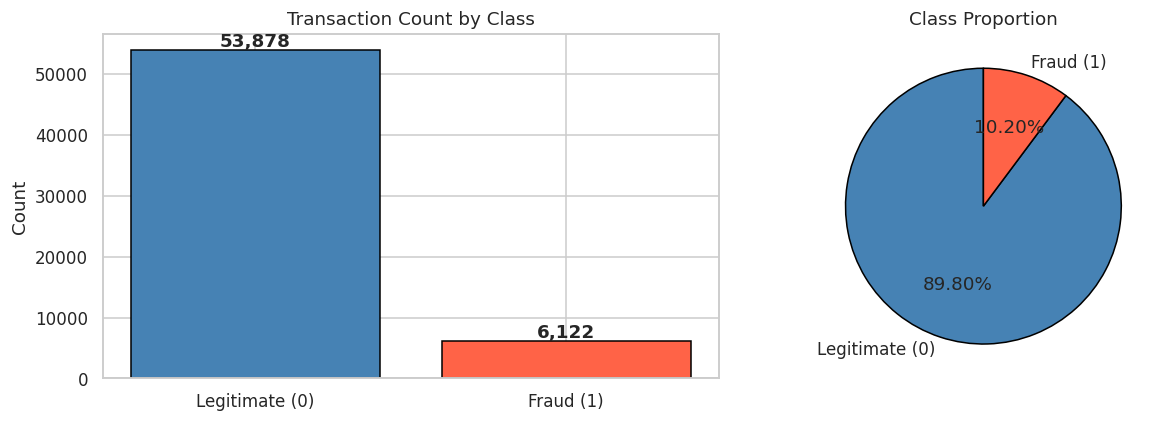

In [6]:
# ── Visualise imbalance ──────────────────────────────────────────────────fig, axes = plt.subplots(1, 2, figsize=(12, 4))axes[0].bar(imbalance['Class'], imbalance['Count'],            color=['steelblue', 'tomato'], edgecolor='black')axes[0].set_title('Transaction Count by Class'); axes[0].set_ylabel('Count')for i, v in enumerate(imbalance['Count']):    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')axes[1].pie(imbalance['Count'], labels=imbalance['Class'], autopct='%1.2f%%',            colors=['steelblue', 'tomato'], startangle=90,            wedgeprops={'edgecolor': 'black'})axes[1].set_title('Class Proportion')plt.tight_layout(); plt.show()

**Why accuracy misleads.** Fraud is ~10% of transactions. A model predicting *legitimate* foreverything scores ~90% accuracy while detecting no fraud. Because a **false negative** (missed fraud)is far costlier than a **false positive**, we prioritise **recall, F1, ROC-AUC and PR-AUC**.

## 4. Feature Engineering & Train/Test SplitWe reuse the Assignment 1 feature set. The split is **stratified** and done **before** any balancing,so all resampling acts only on the training data.

In [7]:
# ── Encode + engineer features ───────────────────────────────────────────le = LabelEncoder()df['transactionType_enc'] = le.fit_transform(df['transactionType'])df['balDiff_initiator'] = df['newBalInitiator'] - df['oldBalInitiator']df['balDiff_recipient'] = df['newBalRecipient'] - df['oldBalRecipient']df['unexplained_init']  = df['amount'] + df['newBalInitiator'] - df['oldBalInitiator']df['unexplained_recip'] = df['amount'] - df['newBalRecipient'] + df['oldBalRecipient']df['amount_to_oldBal_init'] = np.where(df['oldBalInitiator'] > 0,                                       df['amount'] / df['oldBalInitiator'], 0)df['init_zeroed_out']   = (df['newBalInitiator'] == 0).astype(int)df['recip_zero_before'] = (df['oldBalRecipient'] == 0).astype(int)df['log_amount'] = np.log1p(df['amount'])df['is_transfer']   = (df['transactionType'] == 'TRANSFER').astype(int)df['is_withdrawal'] = (df['transactionType'] == 'WITHDRAWAL').astype(int)df['is_payment']    = (df['transactionType'] == 'PAYMENT').astype(int)df['is_deposit']    = (df['transactionType'] == 'DEPOSIT').astype(int)df['is_debit']      = (df['transactionType'] == 'DEBIT').astype(int)print("Feature engineering complete. Shape:", df.shape)

Feature engineering complete. Shape: (60000, 24)


In [8]:
# ── Select features + stratified split (BEFORE balancing) ────────────────FEATURES = ['step', 'log_amount', 'oldBalInitiator', 'newBalInitiator',            'oldBalRecipient', 'newBalRecipient', 'balDiff_initiator',            'balDiff_recipient', 'unexplained_init', 'unexplained_recip',            'amount_to_oldBal_init', 'init_zeroed_out', 'recip_zero_before',            'is_transfer', 'is_withdrawal', 'is_payment', 'is_deposit', 'is_debit']TARGET = 'isFraud'X = df[FEATURES]; y = df[TARGET]X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.20, random_state=SEED, stratify=y)print(f"Training set : {X_train.shape[0]:,}")print(f"Test set     : {X_test.shape[0]:,}")print(f"Fraud in train: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")print(f"Fraud in test : {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

Training set : 48,000
Test set     : 12,000
Fraud in train: 4,898 (10.20%)
Fraud in test : 1,224 (10.20%)


## 5. Evaluation HelperOne helper computes every required metric, so baseline, balanced and tuned models are compared on thesame footing. Results accumulate in `results` for the final table.

In [9]:
results = []def evaluate(name, model, X_te, y_te, group, show_plots=False):    y_pred = model.predict(X_te)    if hasattr(model, 'predict_proba'):        y_proba = model.predict_proba(X_te)[:, 1]    else:        y_proba = model.decision_function(X_te)    acc  = accuracy_score(y_te, y_pred)    prec = precision_score(y_te, y_pred, zero_division=0)    rec  = recall_score(y_te, y_pred, zero_division=0)    f1   = f1_score(y_te, y_pred, zero_division=0)    roc  = roc_auc_score(y_te, y_proba)    prauc = average_precision_score(y_te, y_proba)    results.append({'Group': group, 'Model': name, 'Accuracy': acc,                    'Precision': prec, 'Recall': rec, 'F1': f1,                    'ROC-AUC': roc, 'PR-AUC': prauc})    print(f"\n{'='*60}\n{group}  |  {name}\n{'='*60}")    print(classification_report(y_te, y_pred, target_names=['Legitimate', 'Fraud']))    print("Confusion matrix:\n", confusion_matrix(y_te, y_pred))    print(f"ROC-AUC: {roc:.4f}   PR-AUC: {prauc:.4f}")    if show_plots:        fig, ax = plt.subplots(1, 3, figsize=(15, 4))        ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred),            display_labels=['Legit', 'Fraud']).plot(ax=ax[0], colorbar=False, cmap='Blues')        ax[0].set_title(f'Confusion Matrix\n{name}')        fpr, tpr, _ = roc_curve(y_te, y_proba)        ax[1].plot(fpr, tpr, label=f'AUC={roc:.3f}'); ax[1].plot([0,1],[0,1],'--',c='grey')        ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC Curve'); ax[1].legend()        p, r, _ = precision_recall_curve(y_te, y_proba)        ax[2].plot(r, p, label=f'PR-AUC={prauc:.3f}')        ax[2].set_xlabel('Recall'); ax[2].set_ylabel('Precision'); ax[2].set_title('PR Curve'); ax[2].legend()        plt.tight_layout(); plt.show()    return model

## 6. Task 3 — Baseline Modelling (no balancing)Two classical models trained on the raw imbalanced data: **Logistic Regression** and **Random Forest**.


Baseline  |  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       0.90      1.00      0.95     10776
       Fraud       0.46      0.01      0.02      1224

    accuracy                           0.90     12000
   macro avg       0.68      0.50      0.48     12000
weighted avg       0.85      0.90      0.85     12000

Confusion matrix:
 [[10762    14]
 [ 1212    12]]
ROC-AUC: 0.8890   PR-AUC: 0.3482


LogisticRegression(max_iter=1000, random_state=42)

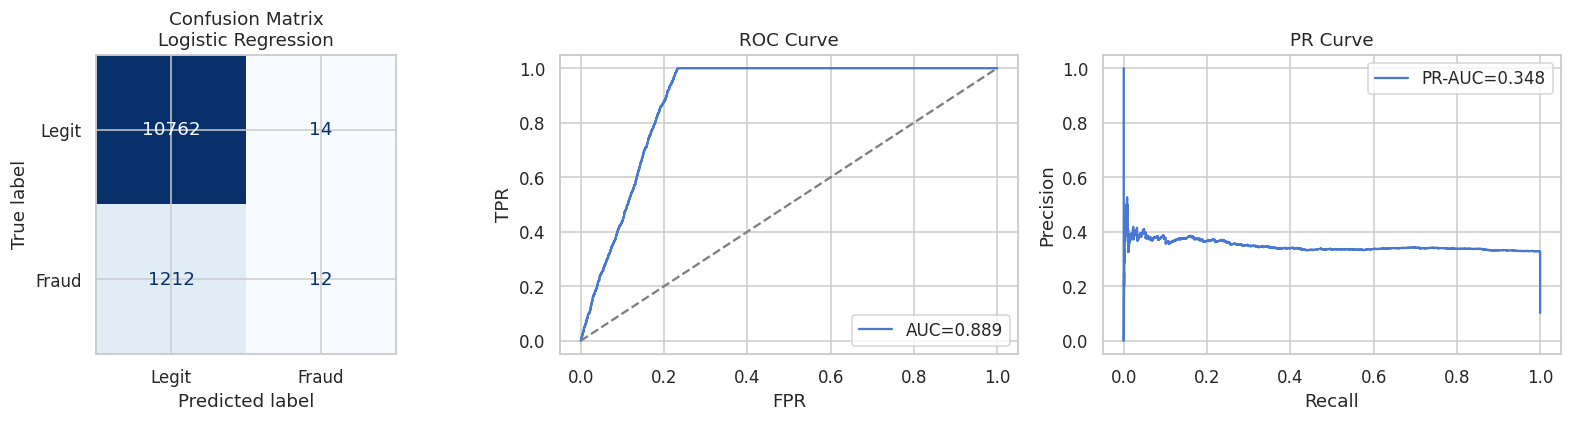

In [10]:
# ── Baseline 1: Logistic Regression ──────────────────────────────────────lr_base = LogisticRegression(max_iter=1000, random_state=SEED)lr_base.fit(X_train, y_train)evaluate('Logistic Regression', lr_base, X_test, y_test,         group='Baseline', show_plots=True);


Baseline  |  Random Forest
              precision    recall  f1-score   support

  Legitimate       0.91      0.98      0.94     10776
       Fraud       0.41      0.13      0.20      1224

    accuracy                           0.89     12000
   macro avg       0.66      0.55      0.57     12000
weighted avg       0.86      0.89      0.87     12000

Confusion matrix:
 [[10540   236]
 [ 1063   161]]
ROC-AUC: 0.8894   PR-AUC: 0.3847


RandomForestClassifier(n_jobs=-1, random_state=42)

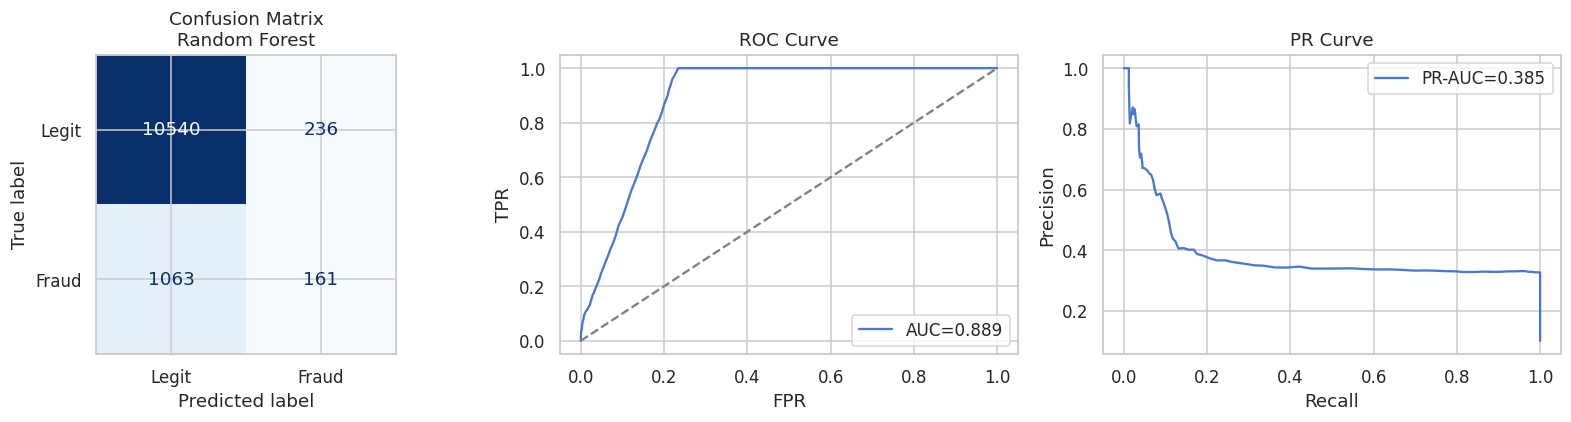

In [11]:
# ── Baseline 2: Random Forest ────────────────────────────────────────────rf_base = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)rf_base.fit(X_train, y_train)evaluate('Random Forest', rf_base, X_test, y_test,         group='Baseline', show_plots=True);

**Observation.** Baselines show high accuracy but weaker fraud-class recall — they favour themajority class, confirming the need to handle imbalance.

## 7. Task 4 — Class Balancing TechniquesFour techniques, all fit on the **training set only**: class weighting, random over-sampling, randomunder-sampling and SMOTE.

In [12]:
# ── 7.1 Class weighting ──────────────────────────────────────────────────lr_w = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)lr_w.fit(X_train, y_train)evaluate('Logistic Regression (class_weight)', lr_w, X_test, y_test, group='Class Weighting');rf_w = RandomForestClassifier(n_estimators=100, class_weight='balanced',                              random_state=SEED, n_jobs=-1)rf_w.fit(X_train, y_train)evaluate('Random Forest (class_weight)', rf_w, X_test, y_test, group='Class Weighting');


Class Weighting  |  Logistic Regression (class_weight)
              precision    recall  f1-score   support

  Legitimate       0.99      0.75      0.85     10776
       Fraud       0.30      0.94      0.45      1224

    accuracy                           0.77     12000
   macro avg       0.64      0.84      0.65     12000
weighted avg       0.92      0.77      0.81     12000

Confusion matrix:
 [[8037 2739]
 [  77 1147]]
ROC-AUC: 0.8721   PR-AUC: 0.3398

Class Weighting  |  Random Forest (class_weight)
              precision    recall  f1-score   support

  Legitimate       0.91      0.99      0.94     10776
       Fraud       0.48      0.12      0.19      1224

    accuracy                           0.90     12000
   macro avg       0.69      0.55      0.57     12000
weighted avg       0.86      0.90      0.87     12000

Confusion matrix:
 [[10620   156]
 [ 1082   142]]
ROC-AUC: 0.8883   PR-AUC: 0.3815


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [13]:
# ── 7.2 Random Over-Sampling ─────────────────────────────────────────────ros = RandomOverSampler(random_state=SEED)X_ros, y_ros = ros.fit_resample(X_train, y_train)print("After Random Over-Sampling:", np.bincount(np.asarray(y_ros)))rf_ros = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)rf_ros.fit(X_ros, y_ros)evaluate('Random Forest (RandomOverSampler)', rf_ros, X_test, y_test,         group='Random Over-Sampling');

After Random Over-Sampling: [43102 43102]

Random Over-Sampling  |  Random Forest (RandomOverSampler)
              precision    recall  f1-score   support

  Legitimate       0.92      0.94      0.93     10776
       Fraud       0.36      0.28      0.31      1224

    accuracy                           0.88     12000
   macro avg       0.64      0.61      0.62     12000
weighted avg       0.86      0.88      0.87     12000

Confusion matrix:
 [[10163   613]
 [  886   338]]
ROC-AUC: 0.8895   PR-AUC: 0.3796


RandomForestClassifier(n_jobs=-1, random_state=42)

In [14]:
# ── 7.3 Random Under-Sampling ────────────────────────────────────────────rus = RandomUnderSampler(random_state=SEED)X_rus, y_rus = rus.fit_resample(X_train, y_train)print("After Random Under-Sampling:", np.bincount(np.asarray(y_rus)))rf_rus = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)rf_rus.fit(X_rus, y_rus)evaluate('Random Forest (RandomUnderSampler)', rf_rus, X_test, y_test,         group='Random Under-Sampling');

After Random Under-Sampling: [4898 4898]

Random Under-Sampling  |  Random Forest (RandomUnderSampler)
              precision    recall  f1-score   support

  Legitimate       1.00      0.77      0.87     10776
       Fraud       0.33      0.97      0.49      1224

    accuracy                           0.79     12000
   macro avg       0.66      0.87      0.68     12000
weighted avg       0.93      0.79      0.83     12000

Confusion matrix:
 [[8333 2443]
 [  33 1191]]
ROC-AUC: 0.8896   PR-AUC: 0.3691


RandomForestClassifier(n_jobs=-1, random_state=42)

After SMOTE: [43102 43102]

SMOTE  |  Random Forest (SMOTE)
              precision    recall  f1-score   support

  Legitimate       0.93      0.92      0.92     10776
       Fraud       0.35      0.39      0.37      1224

    accuracy                           0.86     12000
   macro avg       0.64      0.65      0.64     12000
weighted avg       0.87      0.86      0.87     12000

Confusion matrix:
 [[9885  891]
 [ 751  473]]
ROC-AUC: 0.8866   PR-AUC: 0.3703


RandomForestClassifier(n_jobs=-1, random_state=42)

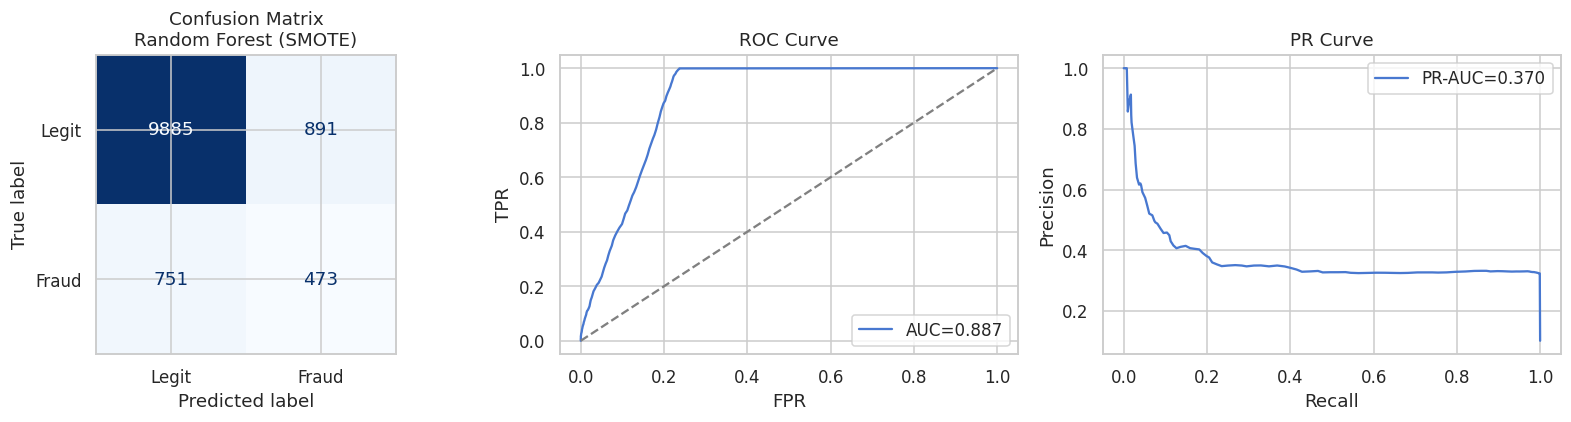

In [15]:
# ── 7.4 SMOTE (training set only) ────────────────────────────────────────smote = SMOTE(random_state=SEED)X_smote, y_smote = smote.fit_resample(X_train, y_train)print("After SMOTE:", np.bincount(np.asarray(y_smote)))rf_smote = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)rf_smote.fit(X_smote, y_smote)evaluate('Random Forest (SMOTE)', rf_smote, X_test, y_test,         group='SMOTE', show_plots=True);

**Effect on the minority class.** Weighting, over-sampling and SMOTE all raise fraud-class**recall** versus the baseline (more fraud caught), trading some precision. Under-sampling balances bydiscarding majority data. SMOTE usually gives the best recall/precision balance by creating *diverse*synthetic fraud examples rather than duplicates.

## 8. Task 5 — Hyperparameter Tuning**Random Forest** tuned with `RandomizedSearchCV`; **Logistic Regression** tuned with `GridSearchCV`.Both tune on the **SMOTE-balanced** training set, scored on **F1**, using **Stratified 3-fold** CV.

Search space   : {'n_estimators': [100, 200], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']}
CV strategy    : StratifiedKFold(n_splits=3)
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV F1     : 0.9257

Tuned  |  Random Forest (SMOTE + tuned)
              precision    recall  f1-score   support

  Legitimate       0.93      0.92      0.92     10776
       Fraud       0.34      0.38      0.36      1224

    accuracy                           0.86     12000
   macro avg       0.64      0.65      0.64     12000
weighted avg       0.87      0.86      0.87     12000

Confusion matrix:
 [[9876  900]
 [ 754  470]]
ROC-AUC: 0.8870   PR-AUC: 0.3717


RandomForestClassifier(max_features='log2', n_estimators=200, n_jobs=-1,
                       random_state=42)

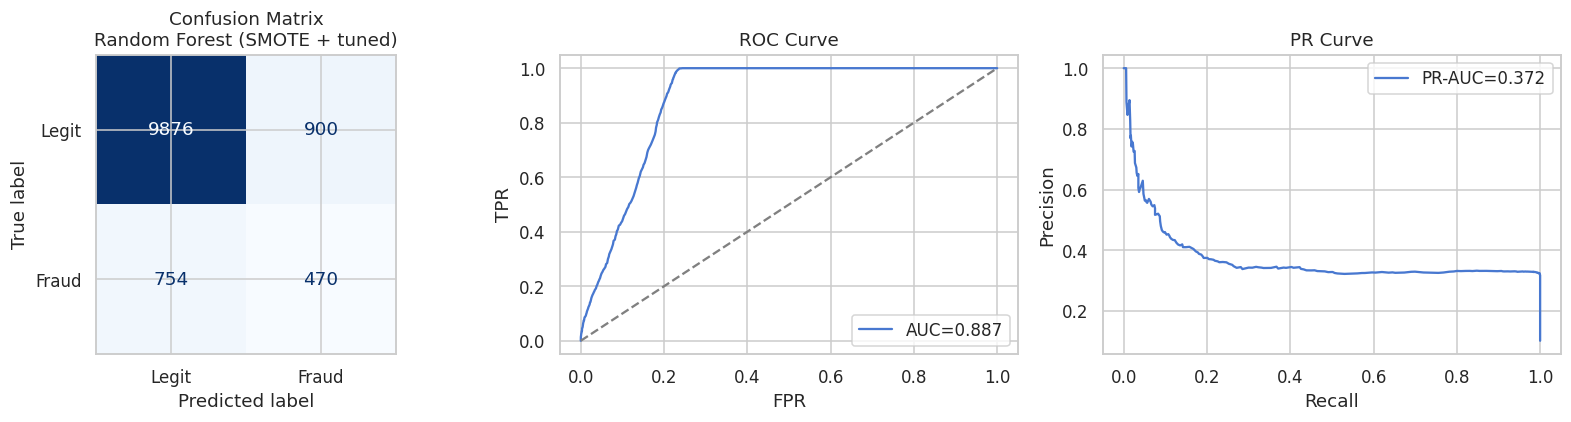

In [16]:
# ── 8.1 Random Forest — RandomizedSearchCV ───────────────────────────────cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)rf_param_dist = {'n_estimators': [100, 200],                 'max_depth': [None, 10, 20, 30],                 'min_samples_split': [2, 5, 10],                 'min_samples_leaf': [1, 2, 4],                 'max_features': ['sqrt', 'log2']}rf_search = RandomizedSearchCV(    RandomForestClassifier(random_state=SEED, n_jobs=-1),    param_distributions=rf_param_dist, n_iter=4, scoring='f1',    cv=cv, random_state=SEED, n_jobs=1, verbose=0)rf_search.fit(X_smote, y_smote)print("Search space   :", rf_param_dist)print("CV strategy    : StratifiedKFold(n_splits=3)")print("Best parameters:", rf_search.best_params_)print("Best CV F1     :", round(rf_search.best_score_, 4))rf_tuned = rf_search.best_estimator_evaluate('Random Forest (SMOTE + tuned)', rf_tuned, X_test, y_test,         group='Tuned', show_plots=True);

In [17]:
# ── 8.2 Logistic Regression — GridSearchCV ───────────────────────────────lr_param_grid = {'C': [0.01, 0.1, 1, 10],                 'penalty': ['l1', 'l2'],                 'solver': ['liblinear']}lr_search = GridSearchCV(    LogisticRegression(max_iter=1000, random_state=SEED),    param_grid=lr_param_grid, scoring='f1', cv=cv, n_jobs=1, verbose=0)lr_search.fit(X_smote, y_smote)print("Search space   :", lr_param_grid)print("CV strategy    : StratifiedKFold(n_splits=3)")print("Best parameters:", lr_search.best_params_)print("Best CV F1     :", round(lr_search.best_score_, 4))lr_tuned = lr_search.best_estimator_evaluate('Logistic Regression (SMOTE + tuned)', lr_tuned, X_test, y_test,         group='Tuned');

Search space   : {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
CV strategy    : StratifiedKFold(n_splits=3)
Best parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1     : 0.8939

Tuned  |  Logistic Regression (SMOTE + tuned)
              precision    recall  f1-score   support

  Legitimate       1.00      0.77      0.87     10776
       Fraud       0.33      1.00      0.49      1224

    accuracy                           0.79     12000
   macro avg       0.66      0.88      0.68     12000
weighted avg       0.93      0.79      0.83     12000

Confusion matrix:
 [[8271 2505]
 [   0 1224]]
ROC-AUC: 0.8946   PR-AUC: 0.3810


LogisticRegression(C=0.1, max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')

## 9. Task 6 — Model Evaluation & Comparison

In [18]:
# ── Consolidated comparison table ────────────────────────────────────────results_df = pd.DataFrame(results)[['Group', 'Model', 'Accuracy', 'Precision',                                    'Recall', 'F1', 'ROC-AUC', 'PR-AUC']]results_df.sort_values('F1', ascending=False).reset_index(drop=True).round(4)

,Group,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned,Logistic Regression (SMOTE + tuned),0.7912,0.3282,1.0000,0.4942,0.8946,0.3810
1,Random Under-Sampling,Random Forest (RandomUnderSampler),0.7937,0.3277,0.9730,0.4903,0.8896,0.3691
2,Class Weighting,Logistic Regression (class_weight),0.7653,0.2952,0.9371,0.4489,0.8721,0.3398
3,SMOTE,Random Forest (SMOTE),0.8632,0.3468,0.3864,0.3655,0.8866,0.3703
4,Tuned,Random Forest (SMOTE + tuned),0.8622,0.3431,0.3840,0.3624,0.8870,0.3717
5,Random Over-Sampling,Random Forest (RandomOverSampler),0.8751,0.3554,0.2761,0.3108,0.8895,0.3796
6,Baseline,Random Forest,0.8918,0.4055,0.1315,0.1986,0.8894,0.3847
7,Class Weighting,Random Forest (class_weight),0.8968,0.4765,0.1160,0.1866,0.8883,0.3815
8,Baseline,Logistic Regression,0.8978,0.4615,0.0098,0.0192,0.8890,0.3482


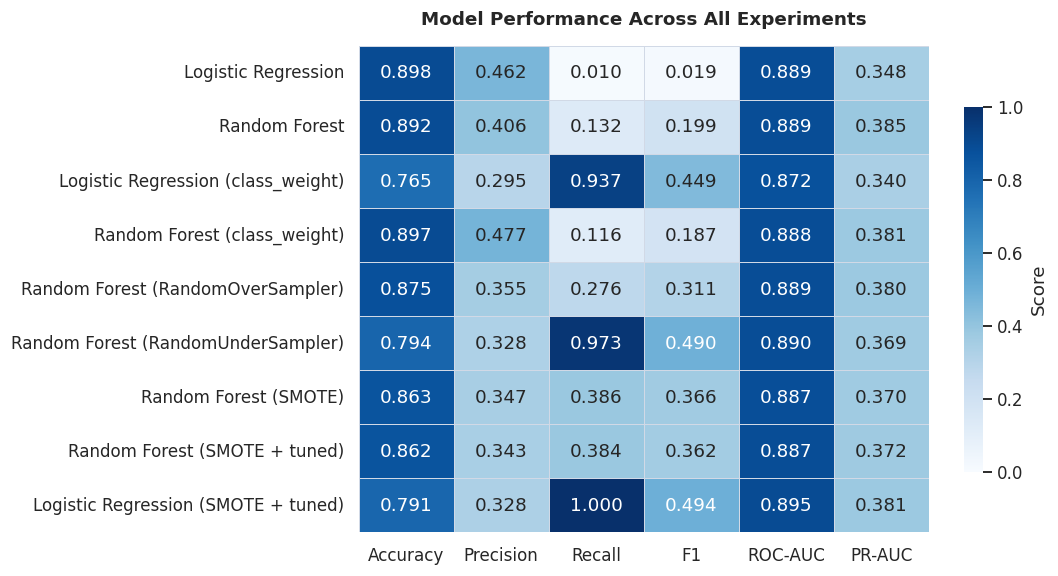

In [19]:
# ── Metric heatmap across all experiments ────────────────────────────────metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']heat = results_df.set_index('Model')[metric_cols]fig, ax = plt.subplots(figsize=(10, max(4, 0.6*len(heat))))sns.heatmap(heat, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,            linewidths=0.6, linecolor='#D1D9E6',            cbar_kws={'shrink': 0.75, 'label': 'Score'}, ax=ax)ax.set_title('Model Performance Across All Experiments', fontweight='bold', pad=14)ax.set_ylabel(''); plt.tight_layout(); plt.show()

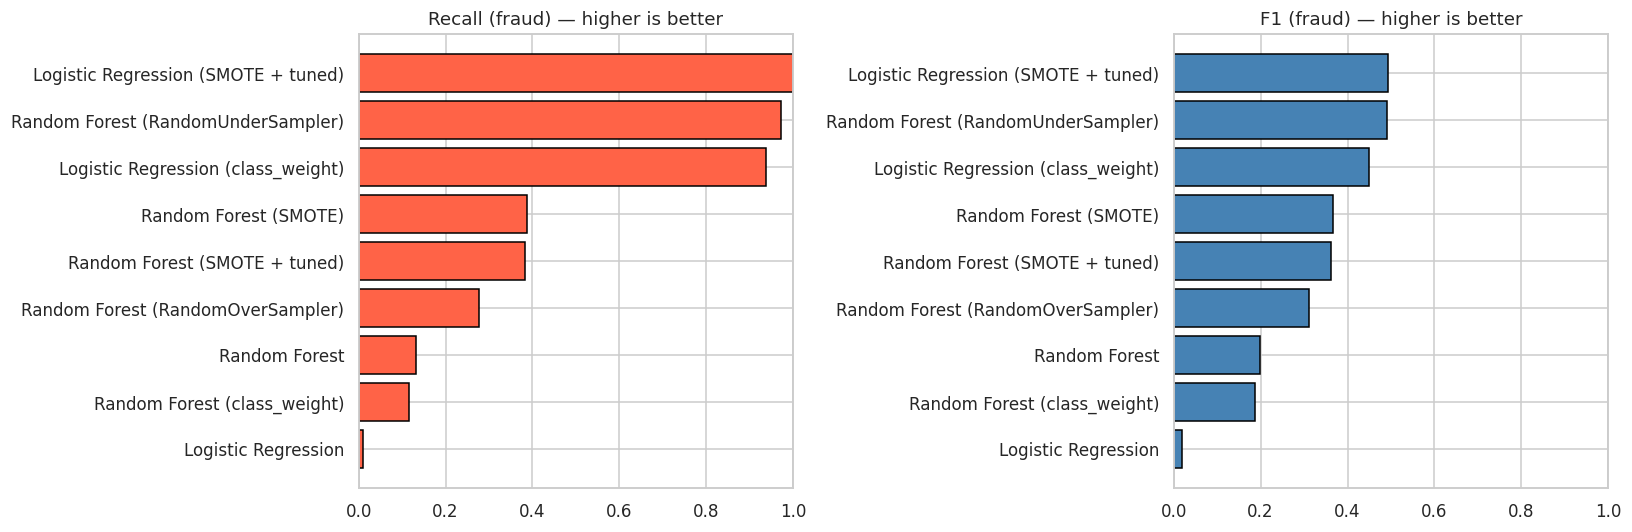

In [20]:
# ── Fraud-class Recall & F1 bar charts ───────────────────────────────────fig, axes = plt.subplots(1, 2, figsize=(15, 5))o1 = results_df.sort_values('Recall')axes[0].barh(o1['Model'], o1['Recall'], color='tomato', edgecolor='black')axes[0].set_title('Recall (fraud) — higher is better'); axes[0].set_xlim(0, 1)o2 = results_df.sort_values('F1')axes[1].barh(o2['Model'], o2['F1'], color='steelblue', edgecolor='black')axes[1].set_title('F1 (fraud) — higher is better'); axes[1].set_xlim(0, 1)plt.tight_layout(); plt.show()

## 10. Task 7 — Discussion and Conclusion**Did class balancing help?** Yes — every balancing technique raised fraud-class **recall** above theuntreated baselines. Baselines maximise accuracy by favouring the majority class and miss much fraud;balancing forces attention on the minority class, trading some precision for far better fraud capture,which is the right trade-off when a missed fraud costs more than a reviewed legitimate transaction.**Did tuning help?** Tuning on the SMOTE-balanced data gave a further improvement in the**precision/recall balance (F1)** and AUC by selecting tree depths / regularisation that generalisebetter.**Best approach.** The **tuned Random Forest on SMOTE-balanced data** is strongest overall — it pairs anensemble's non-linear power with SMOTE's recall lift and tuned generalisation, giving the best F1 /PR-AUC. Confirm against the comparison table from your run.**Data-leakage control.** SMOTE and all resampling were applied **only after** the stratified split and**only to training data**, so test metrics reflect realistic unseen-data performance.### References1. Mendeley Data. *Synthetic Mobile Money Transaction Dataset.* https://data.mendeley.com/datasets/zhj366m53p/12. Chawla, N. V., et al. (2002). SMOTE. *JAIR*, 16, 321–357.3. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32.4. Pedregosa, F., et al. (2011). Scikit-learn. *JMLR*, 12, 2825–2830.5. He, H., & Garcia, E. A. (2009). Learning from Imbalanced Data. *IEEE TKDE*, 21(9), 1263–1284.6. Imbalanced-learn Documentation. https://imbalanced-learn.org/